# Minnesota Food Shelf Exploratory Data Analysis (EDA)

This notebook consolidates data from two sources and presents visualizations that summarize the data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Merging and Cleaning

This section prepares the data for analysis by combining the population information from `bea_mn_2024.csv` and the food shelf list from `food_shelves_scrapedgeocoded_2026.pkl` into a single `county` table.

### Cleaning the County Population Data

Source: `bea_mn_2024.csv`.

The data are from the U.S. Department of Commerce's [Bureau of Economic Analysis (BEA)](https://www.bea.gov/) [calendar year 2024](https://apps.bea.gov/itable/?ReqID=70&step=1&_gl=1*5wit58*_ga*MjEwNjIyNzY4LjE3NzY2MTQ4Nzc.*_ga_J4698JNNFT*czE3NzY2MTQ4NzckbzEkZzEkdDE3NzY2MTQ4ODkkajQ4JGwwJGgw#eyJhcHBpZCI6NzAsInN0ZXBzIjpbMSwyOSwyNSwzMSwyNiwyNywzMF0sImRhdGEiOltbIlRhYmxlSWQiLCIyMCJdLFsiTWFqb3JfQXJlYSIsIjQiXSxbIlN0YXRlIixbIjI3MDAwIl1dLFsiQXJlYSIsWyJYWCJdXSxbIlN0YXRpc3RpYyIsWyItMSJdXSxbIlVuaXRfb2ZfbWVhc3VyZSIsIkxldmVscyJdLFsiWWVhciIsWyIyMDI0Il1dLFsiWWVhckJlZ2luIiwiLTEiXSxbIlllYXJfRW5kIiwiLTEiXV19) data. 
- [The data are also accessible via FRED (Federal Reserve Economic Data).](https://fred.stlouisfed.org/release/tables?eid=267451&rid=175) 
- The data were last updated 5 Feb 2026. 
- The population estimates are from the United States Census Bureau's midyear population estimates, and vary slightly from [the Census' finalized 2024 and 2025 estimates](https://www.census.gov/data/datasets/time-series/demo/popest/2020s-counties-total.html#v2025). For example, the BEA population estimate for Aitkin County is 16,335; the Census estimate is 16,283 for 2024 and 16,252 for 2025.

In [2]:
bea = pd.read_csv("data/bea_mn_2024.csv", header=3)
len(bea)

269

The BEA table has footnotes that need to be removed.

In [3]:
# Displaying the footnotes:
with pd.option_context("display.max_colwidth", None):
    display(bea.loc[:, ["GeoFIPS"]].tail(5))

,GeoFIPS
264,Legend/Footnotes
265,1. U.S. Census Bureau midyear population estimates.
266,2. Per capita personal income is total personal income divided by total midyear population.
267,Note. All dollar estimates are in thousands of current dollars (not adjusted for inflation). Statistics presented in thousands of dollars do not indicate more precision than statistics presented in millions of dollars.
268,"Last updated: February 5, 2026-- new statistics for 2024; revised statistics for 2020-2023."


In [4]:
# Dropping the footnotes:
bea = bea.drop([264, 265, 266, 267, 268])
# Checking the tail:
bea.tail(3)

,GeoFIPS,GeoName,LineCode,Description,2024
261,27173,"Yellow Medicine, MN",1.0,Personal income (thousands of dollars),732553.0
262,27173,"Yellow Medicine, MN",2.0,Population (persons) 1,9373.0
263,27173,"Yellow Medicine, MN",3.0,Per capita personal income (dollars) 2,78156.0


The BEA table has summary rows for the whole state that need to be removed.

In [5]:
# Displaying the summary rows:
bea.head(3)

,GeoFIPS,GeoName,LineCode,Description,2024
0,27000,Minnesota,1.0,Personal income (thousands of dollars),437981871.0
1,27000,Minnesota,2.0,Population (persons) 1,5793151.0
2,27000,Minnesota,3.0,Per capita personal income (dollars) 2,75603.0


In [6]:
# Dropping the MN total rows:
bea = bea.drop([0, 1, 2])
# Checking the head:
bea.head(3)

,GeoFIPS,GeoName,LineCode,Description,2024
3,27001,"Aitkin, MN",1.0,Personal income (thousands of dollars),877408.0
4,27001,"Aitkin, MN",2.0,Population (persons) 1,16335.0
5,27001,"Aitkin, MN",3.0,Per capita personal income (dollars) 2,53713.0


I pivot the table so that each row is a county.

In [7]:
# Pivoting the table so that each row is a county:

# Mapping LineCode to column names:
linecode_map = {1.0: "income", 2.0: "population", 3.0: "income_per_capita"}

# Pivoting and renaming columns:
county = (
    bea[bea["LineCode"].isin(linecode_map.keys())]
    .assign(variable=lambda df: df["LineCode"].map(linecode_map))
    .pivot_table(index="GeoName", columns="variable", values="2024", aggfunc="first")
    .reset_index()
    .rename(columns={"GeoName": "county"})
    .rename_axis(None, axis=1)
)[["county", "income", "population", "income_per_capita"]]

county.head(3)

,county,income,population,income_per_capita
0,"Aitkin, MN",877408.0,16335.0,53713.0
1,"Anoka, MN",24459050.0,376840.0,64906.0
2,"Becker, MN",2246063.0,35444.0,63369.0


I perform some common sense checks to verify the data are internally consistent.

In [8]:
# Checking the number of counties correctly equals 87:
print(f"Total number of counties: {len(county)}\n")

# Checking the sums given by the BEA:
# Total MN population according to the BEA: 5793151.0
print(f"Total MN population: {county['population'].sum()}")
# Total personal MN income according to the BEA: 437981871.0
print(f"Total MN personal income (in thousands of $): {county['income'].sum()}\n")

# Checking the per capita calculation:
aitkin_inc = county.at[0, "income"]
aitkin_pop = county.at[0, "population"]
aitkin_cap = county.at[0, "income_per_capita"]
print(f"Aitkin County income: {aitkin_inc}")
print(f"Aitkin County population: {aitkin_pop}")
print(f"Aitkin County income per capita (from BEA): {aitkin_cap}")
print(
    f"Aitkin County income per capita (calculated): {round((aitkin_inc * 1000.0) / aitkin_pop,0)}"
)

Total number of counties: 87

Total MN population: 5793151.0
Total MN personal income (in thousands of $): 437981871.0

Aitkin County income: 877408.0
Aitkin County population: 16335.0
Aitkin County income per capita (from BEA): 53713.0
Aitkin County income per capita (calculated): 53713.0


I standardize the county names.

In [9]:
# Standardizing county names:
county["county"] = county["county"].str.replace(", MN", "")
county[["county"]].sample(5, random_state=42).sort_values("county")

,county
0,Aitkin
12,Chisago
22,Fillmore
26,Hennepin
76,Todd


I check if there are non-integer `income` or `population` values, and then cast to `int`:

In [10]:
# Checking for non-whole values:
print(
    county.loc[county["income"] % 1 != 0, "income"].count(),
    county.loc[county["population"] % 1 != 0, "population"].count(),
    county.loc[county["income_per_capita"] % 1 != 0, "income_per_capita"].count(),
)

0 0 0


In [11]:
# Casting to int:
county["income"] = county["income"].astype("int")
county["population"] = county["population"].astype("int")
county["income_per_capita"] = county["income_per_capita"].astype("int")

# Example row:
county.loc[county["county"] == "Ramsey"]

,county,income,population,income_per_capita
61,Ramsey,38900092,542015,71769


### Cleaning the Food Shelf Data

Source: `food_shelves_scrapedgeocoded_2026.pkl`.

The data were scraped from the Food Group's [Find Help Map](https://www.hungersolutions.org/find-help/) on 04/30/26 using `scrape_and_geocode.py`. 
- See `food_shelf_list_reconciliation.ipynb` for details on how this list of shelves was compiled and how it compares to similar lists.

In [12]:
shelf = pd.read_pickle("data/food_shelves_scrapedgeocoded_2026.pkl")
len(shelf)

549

I manually add two food shelves that weren't scraped correctly:

In [13]:
# Manually adding missing food shelves:

# Adding Comunidades Latinas Unidas En Servicio (CLUES)- Saint Paul
# Adding Second Harvest Northland: Koochiching County
new_rows = pd.DataFrame(
    [
        {
            "name": "Comunidades Latinas Unidas En Servicio (CLUES)- Saint Paul",
            "address": "797 E 7th St, Saint Paul, MN 55106",
            "lat": pd.NA,
            "lng": pd.NA,
            "county": "Ramsey County",
        },
        {
            "name": "Second Harvest Northland: Koochiching County",
            "address": "10370 MN-11, Birchdale, MN, USA",
            "lat": pd.NA,
            "lng": pd.NA,
            "county": "Koochiching County",
        },
    ]
)
shelf = pd.concat([shelf, new_rows], ignore_index=True)
len(shelf)

/var/folders/xn/9fwvzcw14bjfqgqz3dl2x1840000gn/T/ipykernel_48898/1929479413.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  shelf = pd.concat([shelf, new_rows], ignore_index=True)


551

I check for any duplicate shelves.

In [14]:
# Checking for dulicate food shelf names that require further investigation:
shelf.duplicated(subset="name").sum()

np.int64(1)

In [15]:
# Investigating the duplicate further:
shelf.loc[shelf.duplicated(subset="name", keep=False)]

,name,address,lat,lng,county
434,Second Harvest Northland: Itasca County,"51272 State Hwy 46, Squaw Lake, MN, USA",47.617820,-94.132358,Itasca County
435,Second Harvest Northland: Itasca County,"53714 County Road 146, Inger, MN, USA",47.552979,-93.980671,Itasca County


These are two different stops for Second Harvest Northland's [Mobile Food Pantry Program](https://secondharvestnorthland.org/find-food/mobile-food-pantry-program/).

The Find Help Map considers these to be distinct service locations, and I will too; we'll leave them untouched.

In [16]:
# Checking for missing or mangled counties:
shelf.loc[shelf["county"].isna() | (shelf["county"].str.len() < 10), "county"].count()

np.int64(0)

I standardize the county names.

In [17]:
shelf["county"] = shelf["county"].str.replace("County", "")
shelf["county"] = shelf["county"].str.strip()

print(f"Unique county names: {shelf['county'].nunique()}")

Unique county names: 90


The food shelf list has more than 87 counties because it has shelves in non-Minnesota counties.

#### Food Shelves outside Minnesota

16 food shelves on our list aren't in Minnesota.

In [18]:
# Display non-Minnesota food shelves:
(
    shelf.loc[~shelf["address"].str.contains("MN")]
    .loc[~shelf["address"].str.contains("Mn")]
    .loc[~shelf["address"].str.contains("Minnesota")]
    .loc[:, ["name", "address", "county"]]
)

,name,address,county
66,Century College Food Pantry,Century College,Washington
101,Deer River Area Food Shelf,Goodall Resource Center,Itasca
106,Dorothy Day Food Pantry West Fargo,"45 21st Ave W, West Fargo, ND 58078, USA",Cass
117,Emergency Food Pantry,"1101 4th Ave N, Fargo, ND 58102, USA",Cass
123,Family Pathways Frederic,"1100 Wisconsin Ave, Frederic, WI 54837, USA",Polk
129,Family Pathways St. Croix Falls,"2000 U.S. 8, St Croix Falls, WI 54024, USA",Polk
323,New Life Center,"1902 3rd Ave N, Fargo, ND 58102, USA",Cass
362,Pierce County Food Pantry,"440 N Maple St, Ellsworth, WI 54011, USA",Pierce
389,Richland Wilkin Food Pantry,"699 8th Ave S, Wahpeton, ND 58075",Richland
404,Salvation Army Fargo,"304 Roberts Street, Fargo, ND 58102",Cass


Three of these rows (indexes 66, 101, and 540) are Minnesota food shelves with mangled addresses, but the rest are in Wisconsin and North Dakota. (Minnesota and North Dakota both have a Cass County.)

 These particular shelves seem to have been included on the Food Group's list for two reaons: most are geographically close to Minnesota, and some are part of a Minnesota organization's multi-state service area.
 
Looking at Richland Wilkin Food Pantry (index 389) on the [Find Help Map](https://www.hungersolutions.org/find-help/?fwp_proximity=46.2920705%2C-96.5204806%2C5%2CBreckenridge%252C%2520MN%252056520%252C%2520USA&fwp_categories=food-shelves) is illustrative:

![A screenshot of the Food Group's Find Help Map showing the Richland Wilkin Food Pantry](images/WilkinCountyFoodShelf.png)

Wilkin County's closest food shelf is in Richland County, North Dakota.

In [19]:
wilkin_num_shelf = shelf.loc[shelf["county"] == "Wilkin", "name"].count()
print(f"Number of Food Shelves in Wilkin County: {wilkin_num_shelf}")

Number of Food Shelves in Wilkin County: 0


Because the Richland Wilkin Food Pantry is across state lines, it doesn't appear in my query.

My analysis only examines Minnesota counties. However, the main focus of the analysis is service availability, and this food shelf is available to Wilkin County residents. As such, I want to "count" it as a Wilkin county shelf for the purposes of my analysis.

I manually increment the county's food shelf count by altering the shelf's `county`; because I'm not using `address` in my analysis, creating this discrepency is acceptable.

The same turns out to be true for 14 of the 16 non-Minnesota food shelves, and so I manually re-assign each one to the appropriate Minnesota county.

In [20]:
# Re-assigning non-MN shelves to the corresponding MN county:

# Richland County to Wilkin County:
shelf.loc[shelf["name"] == "Richland Wilkin Food Pantry", "county"] = "Wilkin"

# Cass County (Fargo, ND) to Clay County (Moorhead, MN):
shelf.loc[shelf["name"] == "Dorothy Day Food Pantry West Fargo", "county"] = "Clay"
shelf.loc[shelf["name"] == "Emergency Food Pantry", "county"] = "Clay"
shelf.loc[shelf["name"] == "New Life Center", "county"] = "Clay"
shelf.loc[shelf["name"] == "Salvation Army Fargo", "county"] = "Clay"
shelf.loc[shelf["name"] == "St. Mary’s Food Pantry", "county"] = "Clay"

# Polk County to Chisago County:
shelf.loc[shelf["name"] == "Family Pathways Frederic", "county"] = "Chisago"
shelf.loc[shelf["name"] == "Family Pathways St. Croix Falls", "county"] = "Chisago"

# Pierce County to Goodhue County (Red Wing, MN):
shelf.loc[shelf["name"] == "Pierce County Food Pantry", "county"] = "Goodhue"
shelf.loc[shelf["name"] == "Spring Valley Community Food Pantry", "county"] = "Goodhue"

# Grand Forks County to Polk County:
shelf.loc[shelf["name"] == "Salvation Army Grand Forks Food Shelf", "county"] = "Polk"
shelf.loc[shelf["name"] == "St. Joseph’s Social Care Food Pantry", "county"] = "Polk"

Second Harvest Northland: Douglas County (11523 S Business 53, Solon Springs, WI 54873; Douglas County) is 30+ mi (~40 min) from Duluth, MN. Second Harvest Northland: Iron County (606-607 3rd Avenue North, Hurley, WI 54534; Iron County) is 100+ mi (~2 hr) from Duluth, MN.

It doesn't seem reasonable to consider these available to Minnesota residents, so I drop them from the list.

In [21]:
# Dropping WI Second Harvest Northland locations:
shelf = shelf.drop(
    index=[
        shelf.loc[shelf["name"] == "Second Harvest Northland: Douglas County"].index[0],
        shelf.loc[shelf["name"] == "Second Harvest Northland: Iron County"].index[0],
    ]
)

len(shelf)

549

With all non-Minnesota food shelves re-assigned or deleted, the total number of unique counties should equal 87.

In [22]:
print(f"Unique county names: {shelf['county'].nunique()}")
print(f"Number of food shelves: {len(shelf)}")

Unique county names: 87
Number of food shelves: 549


A final step is to compare the county lists to make sure they will merge correctly:

In [23]:
# Checking for discrepencies between county and shelf:
bea_counties = county["county"].unique()
shelf_counties = shelf["county"].unique()

for c in bea_counties:
    if c not in shelf_counties:
        print(f"{c} is unmatched.")

My list is finalized and ready to merge.

As a point of interest, this is my last chance with the food shelf-level data, so I'll do a brief exploration of the major players in terms of number of locations served.

In [24]:
# Fixing an inconsistency in how different Food Shelf In-A-Box locations are named:
shelf["name"] = shelf["name"].str.replace("Foodshelf-In-A-Box", "Food Shelf In-A-Box")

In [25]:
# Checking the full list of shelves for common organization names, then counting the shelves:
# with pd.option_context("display.max_rows", None):
#    display(shelf.loc[:,'name'])
groups = pd.DataFrame(
    {
        "group": [
            "360 Communities",
            "Bountiful Basket",
            "Campus Cupboard",
            "Catholic Charities",
            "CLUES",
            "Dorothy Day",
            "Family Pathways",
            "Food Shelf In-A-Box",
            "Heaven’s Table Food Shelf",
            "Hope for the Community",
            "MAS MN",
            "Mille Lacs Band of Ojibwe Food Shelf",
            "Neighbors Express",
            "Nutritious U Food Pantry",
            "Outreach Food Shelf Mobile Pantry",
            "Salvation Army",
            "Second Harvest",
            "SEMCAC",
            "The Open Door Mobile Pantry",
            "The Sanneh Foundation",
            "VEAP",
        ]
    }
)

groups["count"] = groups["group"].apply(
    lambda g: shelf["name"].str.contains(g, case=False, regex=False).sum()
)

groups.loc[groups["count"] > 3].sort_values("count", ascending=False).reset_index(
    drop=True
).rename(columns={"group": "Organization", "count": "Shelf Count"})

,Organization,Shelf Count
0,Salvation Army,25
1,Food Shelf In-A-Box,24
2,Second Harvest,17
3,Catholic Charities,10
4,Family Pathways,10
5,Hope for the Community,9
6,The Sanneh Foundation,7
7,Neighbors Express,6
8,360 Communities,5
9,Outreach Food Shelf Mobile Pantry,4


4.73% of food shelves in Minnesota are run under the Salvation Army name. 

In general, the story the food shelf list tells is the importance of local organizations: the majority of shelves serve only one location.

We also see provision methods that augment brick-and-mortar locations - such as Outreach Food Shelf's [Mobile Pantry](https://outreachfoodshelf.com/find-help/) and Second Harvest Northland's [Mobile Food Pantry Program](https://secondharvestnorthland.org/find-food/mobile-food-pantry-program/) - or operate without one, such as Good in the 'Hood's [Food Shelf In-A-Box](https://www.goodinthehood.org/food-programs/food-shelf-in-a-box) program.

### Merging the Tables

In [26]:
# Counting food shelves per county:
shelf_counts = shelf.groupby("county", as_index=False).agg(count=("name", "count"))

# Merging the tables:
county = pd.merge(county, shelf_counts, on="county", how="left")

# Displaying the columns and null-counts:
county.isna().sum()

county               0
income               0
population           0
income_per_capita    0
count                0
dtype: int64

### Creating `count_per_10k`

I create the column `count_per_10k`, the proportion of food shelves per 10,000 residents.

In [27]:
# Creating count_per_10k:
county["count_per_10k"] = np.round(county["count"] / (county["population"] / 10_000), 4)

In [28]:
# Displaying the counties with the largest number of food shelves:
county.loc[:, ["county", "population", "count", "count_per_10k"]].sort_values(
    "count", ascending=False
).head(6)

,county,population,count,count_per_10k
26,Hennepin,1273334,99,0.7775
61,Ramsey,542015,38,0.7011
18,Dakota,453156,23,0.5076
71,St. Louis,200794,21,1.0458
72,Stearns,163997,20,1.2195
1,Anoka,376840,19,0.5042


In [29]:
# Displaying all counties with only one food shelf:
county.loc[county["count"] < 2, ["county", "population", "count", "count_per_10k"]]

,county,population,count,count_per_10k
2,Becker,35444,1,0.2821
14,Clearwater,8630,1,1.1587
36,Lac qui Parle,6636,1,1.5069
37,Lake of the Woods,3797,1,2.6337
56,Pennington,13652,1,0.7325
58,Pipestone,9100,1,1.0989
60,Pope,11495,1,0.8699
64,Renville,14453,1,0.6919
66,Rock,9525,1,1.0499
74,Stevens,9819,1,1.0184


### Creating `tcmetro`

I create the column `tcmetro`, a marker that classifies a county's inclusion or exclusion in the Twin Cities metropolitan area:
- `3`: Counties that include the Twin Cities: Hennepin and Ramsey.
- `2`: Counties in the seven-county metropolitan area governed by the Metropolitan Council: Anoka, Carver, Dakota, Hennepin, Ramsey, Scott, and Washington.
- `1`: Counties in the fifteen-county "Minneapolis–St. Paul–Bloomington MN–WI Metropolitan Statistical Area" designated by the Office of Management and Budget (OMB), excluding the two Wisconsin counties of St. Croix and Pierce: Anoka, Carver, Chisago, Dakota, Hennepin, Isanti, Le Sueur, Mille Lacs, Ramsey, Scott, Sherburne, Washington, and Wright.
- `0`: Counties outside the metropolitan area. 

In [30]:
# The lists of counties in each metropolitan classification:
tc = ["Hennepin", "Ramsey"]

seven_county_metro = [
    "Anoka",
    "Carver",
    "Dakota",
    "Hennepin",
    "Ramsey",
    "Scott",
    "Washington",
]

statistical_area = [
    "Anoka",
    "Carver",
    "Chisago",
    "Dakota",
    "Hennepin",
    "Isanti",
    "Le Sueur",
    "Mille Lacs",
    "Ramsey",
    "Scott",
    "Sherburne",
    "Washington",
    "Wright",
]

In [31]:
# Creating tcmetro:
county["tcmetro"] = 0

county.loc[county["county"].isin(tc), "tcmetro"] += 1
county.loc[county["county"].isin(seven_county_metro), "tcmetro"] += 1
county.loc[county["county"].isin(statistical_area), "tcmetro"] += 1

county.sample(5, random_state=42)

,county,income,population,income_per_capita,count,count_per_10k,tcmetro
76,Todd,1675174,25955,64541,3,1.1558,0
0,Aitkin,877408,16335,53713,6,3.6731,0
26,Hennepin,127781586,1273334,100352,99,0.7775,3
22,Fillmore,1261143,21502,58652,5,2.3254,0
12,Chisago,3791769,59105,64153,5,0.8460,1


In [32]:
# Checking that the counts are accurate:
print(f"Unique metro categories: {county['tcmetro'].nunique()}")
print(
    f"Number of counties in the Twin Cities core: {county.loc[county['tcmetro'] == 3,'county'].count()}"
)
print(
    f"Number of counties in the Seven-County Metro: {county.loc[county['tcmetro'] >= 2,'county'].count()}"
)
print(
    f"Number of counties in the Metro Statistical Area: {county.loc[county['tcmetro'] >= 1,'county'].count()}"
)
print(
    f"Number of counties in the Non-Metro area: {county.loc[county['tcmetro'] == 0,'county'].count()}"
)

Unique metro categories: 4
Number of counties in the Twin Cities core: 2
Number of counties in the Seven-County Metro: 7
Number of counties in the Metro Statistical Area: 13
Number of counties in the Non-Metro area: 74


According to Wikipedia, [the Metropolitan Council](https://en.wikipedia.org/wiki/Metropolitan_Council_(Minnesota)) serves over 55% of Minnesota's population. I verify that my data agree with this number:

In [33]:
# Comparing Seven-county metro and non-metro population sums:
pd.concat(
    [
        county.groupby(county["tcmetro"] > 1)["population"]
        .sum()
        .to_frame()
        .rename(columns={"population": "total_pop"}),
        county.groupby(county["tcmetro"] > 1)["population"].sum()
        / county["population"].sum(),
    ],
    axis=1,
).rename(
    columns={"population": "proportion of pop"},
    index={False: "Non-Metro", True: "Seven-county metro"},
).sort_values(
    "total_pop", ascending=False
)

,total_pop,proportion of pop
tcmetro,,
Seven-county metro,3199139,0.552228
Non-Metro,2594012,0.447772


Finally, I need labels for when for I use the `tcmetro` variable in plots:

In [34]:
tcmetro_labels = {
    3: "Twin Cities core",
    2: "Seven-county metro",
    1: "Metro Statistical Area",
    0: "Non-metro",
}

---

## 2. Exploratory Data Analysis

### Food Shelf Count Analysis

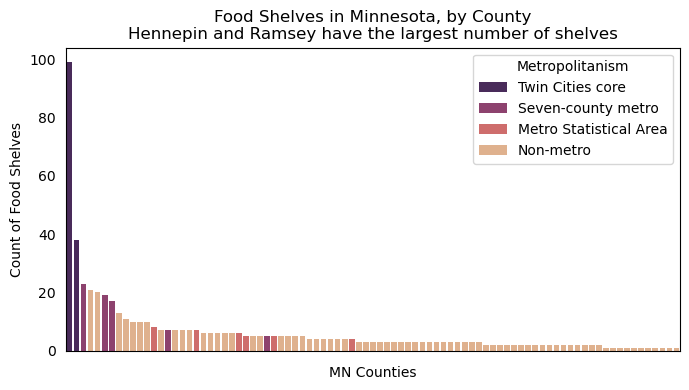

In [35]:
# Bar plot of food shelf count, by county:
fig, ax = plt.subplots(figsize=(7, 4))

sns.barplot(
    data=county.sort_values("count", ascending=False),
    x="county",
    y="count",
    ax=ax,
    hue="tcmetro",
    palette="flare",
)

ax.set_title(
    "Food Shelves in Minnesota, by County\nHennepin and Ramsey have the largest number of shelves"
)
ax.tick_params(left=False, bottom=False)
ax.set_xticklabels([])
ax.set_xlabel("MN Counties")
ax.set_ylabel("Count of Food Shelves")

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1],
    [tcmetro_labels[int(l)] for l in labels[::-1]],
    title="Metropolitanism",
)

plt.tight_layout()
plt.show()

I expect the largest counties to have the highest number of food shelves, and that's exactly what's suggested by the bar plot.

The Twin Cities core (Hennepin and Ramsey) has 25% of Minnesota's total food shelves, as the table below shows.

In [36]:
# Comparing TC core and non-TC core food shelf counts:
temp_shelf_counts = (
    county.groupby(county["tcmetro"] > 2)["count"]
    .sum()
    .to_frame()
    .rename(index={False: "Outside the Twin Cities", True: "Twin Cities core"})
)
temp_shelf_counts.loc["Total"] = temp_shelf_counts["count"].sum()
temp_shelf_counts["proportion"] = np.round(
    temp_shelf_counts["count"] / temp_shelf_counts.loc["Total", "count"], 2
)
temp_shelf_counts

,count,proportion
tcmetro,,
Outside the Twin Cities,412,0.75
Twin Cities core,137,0.25
Total,549,1.00


The relationship between population and food shelf count can be observed directly with a scatter plot:

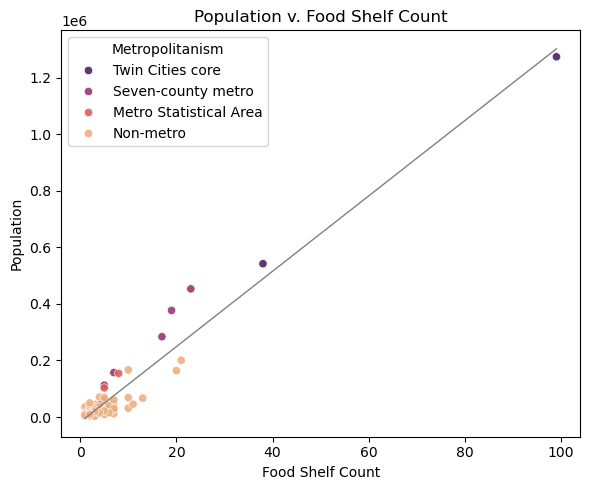

In [37]:
# Scatterplot of
fig, ax = plt.subplots(figsize=(6, 5))

sns.scatterplot(
    data=county,
    x="count",
    y="population",
    hue="tcmetro",
    hue_order=[0, 1, 2, 3],
    palette="flare",
    alpha=0.9,
    edgecolor="white",
    ax=ax,
)

sns.regplot(
    data=county,
    x="count",
    y="population",
    scatter=False,
    color="gray",
    line_kws={"linewidth": 1},
    ci=None,
    ax=ax,
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1],
    [tcmetro_labels[int(l)] for l in labels[::-1]],
    title="Metropolitanism",
)


ax.set_xlabel("Food Shelf Count")
ax.set_ylabel("Population")
ax.set_title("Population v. Food Shelf Count")
plt.tight_layout()
plt.show()

Next, we correct for population:

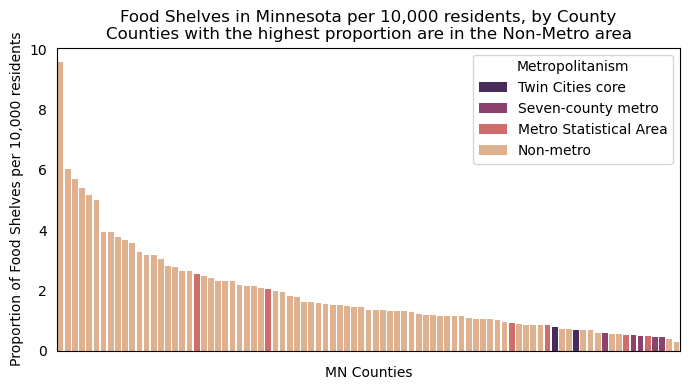

In [38]:
# Bar plot of food shelf per 10k, by county:
fig, ax = plt.subplots(figsize=(7, 4))

sns.barplot(
    data=county.sort_values("count_per_10k", ascending=False),
    x="county",
    y="count_per_10k",
    ax=ax,
    hue="tcmetro",
    palette="flare",
)

ax.set_title(
    "Food Shelves in Minnesota per 10,000 residents, by County\nCounties with the highest proportion are in the Non-Metro area"
)
ax.tick_params(left=False, bottom=False)
ax.set_xticklabels([])
ax.set_xlabel("MN Counties")
ax.set_ylabel("Proportion of Food Shelves per 10,000 residents")

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1],
    [tcmetro_labels[int(l)] for l in labels[::-1]],
    title="Metropolitanism",
)

plt.tight_layout()
plt.show()

Wow! Correcting for population, the first 19 counties are in the non-metropolitan area. 

The top counties are geographically dispersed: Traverse is in western MN, Koochiching is in northern MN, Marshall is in northwestern MN, and Lincoln is in southwestern MN.

As we see from the tables below, the metropolitan county with the highest proportion of food shelves to 10k population is Mille Lacs. In the seven-county area, Hennepin has the highest proportion. 

In [39]:
# The counties with the highest proportion of food shelves to population:
county.loc[
    county["count_per_10k"] > 4, ["county", "population", "count", "count_per_10k"]
].sort_values("count_per_10k", ascending=False)

,county,population,count,count_per_10k
77,Traverse,3134,3,9.5724
35,Koochiching,11594,7,6.0376
43,Marshall,8771,5,5.7006
40,Lincoln,5564,3,5.3918
62,Red Lake,3882,2,5.1520
34,Kittson,3992,2,5.0100


In [40]:
# The top 10 metro counties with the highest proportion of food shelves to population:
county.loc[
    county["tcmetro"] > 0, ["county", "population", "count", "count_per_10k"]
].sort_values("count_per_10k", ascending=False).head(10)

,county,population,count,count_per_10k
47,Mille Lacs,27577,7,2.5383
39,Le Sueur,29458,6,2.0368
29,Isanti,43687,4,0.9156
12,Chisago,59105,5,0.8460
26,Hennepin,1273334,99,0.7775
61,Ramsey,542015,38,0.7011
81,Washington,283960,17,0.5987
85,Wright,154593,8,0.5175
18,Dakota,453156,23,0.5076
1,Anoka,376840,19,0.5042


In [41]:
# The county in the seven-county area with the highest proportion of food shelves to population:
county.loc[
    county["tcmetro"] > 1, ["county", "population", "count", "count_per_10k"]
].sort_values("count_per_10k", ascending=False).head(1)

,county,population,count,count_per_10k
26,Hennepin,1273334,99,0.7775


Examining the food shelves in the top two counties, I see some of the same trends I encountered when cleaning the data.

In [42]:
# Traverse county food shelves:
shelf.loc[shelf["county"] == "Traverse", ["name", "address", "county"]]

,name,address,county
41,Browns Valley Food Shelf,"106 4th St S, Browns Valley, MN 56219, USA",Traverse
508,Traverse County Food Shelf,"15 10th St S, Wheaton, MN, USA",Traverse
540,Wheaton Community Food Shelf,First Presbyterian Church,Traverse


What explains three food shelves for a population of 3,134 people?

For Traverse specifically, it's likely that these food shelves see traffic from the county's non-Minnesota neighbors: North Dakota, South Dakota, and the Lake Traverse Indian Reservation.

In [43]:
# Koochiching county food shelves:
shelf.loc[shelf["county"] == "Koochiching", ["name", "address", "county"]]

,name,address,county
246,KCFA Food Shelf,"Boarderland Alano Club, 410 5th Ave, Internati...",Koochiching
332,Northome Community Food Shelf,"12059 Main Street, Northome, MN 56661",Koochiching
378,Rainy River Community College School Pantry-Fa...,"1801 U.S. 71, International Falls, MN, USA",Koochiching
408,Salvation Army International Falls,"1301 3rd Ave W, International Falls, MN 56649",Koochiching
427,Second Harvest Northland: Big Falls Mobile Pantry,"410 2nd St SW, Big Falls, MN, USA",Koochiching
428,Second Harvest Northland: Birchdale Mobile,"10370 M-11 Birchdale, MN 56629",Koochiching
550,Second Harvest Northland: Koochiching County,"10370 MN-11, Birchdale, MN, USA",Koochiching


For Koochiching, three of the shelves are mobile service options.

More broadly, these results clarify what the data actually show: it's probably more correct to say that food shelves serve *areas*, not *people*. This analysis doesn't study area (or related measures such as distance to closest food shelf or available transportation options), but even without data we can broadly postulate that lower population means less population density. Options like Mobile food shelves - some of which are only available once per month - show how providers can creatively cover a broader area.

### Income Analysis

Although it's tangential to our analysis, we can also investigate the relationship between a county's personal income and its population.

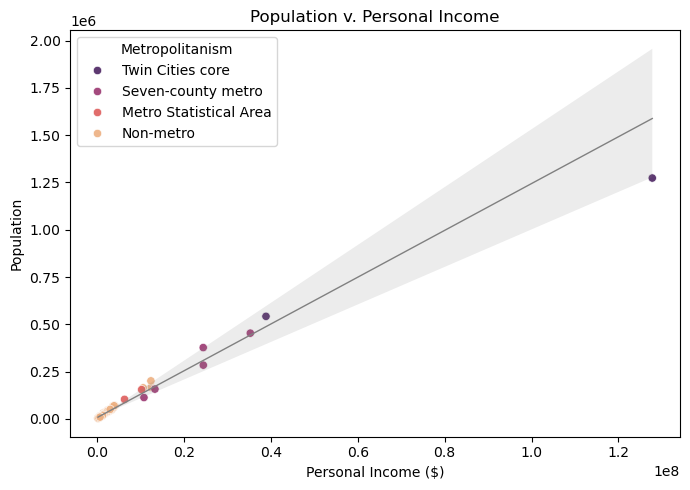

In [44]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.scatterplot(
    data=county,
    x="income",
    y="population",
    hue="tcmetro",
    hue_order=[0, 1, 2, 3],
    palette="flare",
    alpha=0.9,
    edgecolor="white",
    ax=ax,
)

sns.regplot(
    data=county,
    x="income",
    y="population",
    scatter=False,  # don't re-plot the dots
    color="gray",
    line_kws={"linewidth": 1},
    robust=True,
    ax=ax,
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1],
    [tcmetro_labels[int(l)] for l in labels[::-1]],
    title="Metropolitanism",
)


ax.set_xlabel("Personal Income ($)")
ax.set_ylabel("Population")
ax.set_title("Population v. Personal Income")
plt.tight_layout()
plt.show()

There's a tight, fairly linear relationship between personal income and population. Using a robust linear regression limits the effect outliers (particularly Hennepin County) have on the line.

If we control for population, is there any relationship between personal income and food shelf counts?

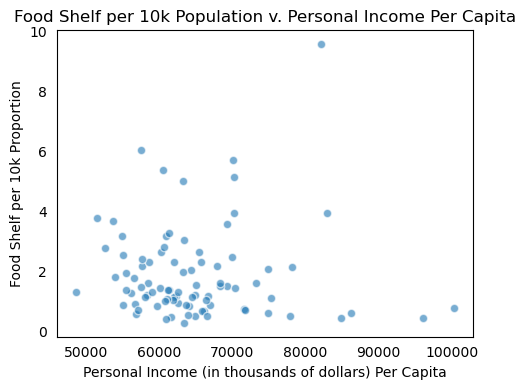

In [45]:
fig, ax = plt.subplots(figsize=(5, 4))

ax.scatter(
    county["income_per_capita"], county["count_per_10k"], alpha=0.6, edgecolors="white"
)

ax.tick_params(left=None, bottom=None)
ax.set_xlabel("Personal Income (in thousands of dollars) Per Capita")
ax.set_ylabel("Food Shelf per 10k Proportion")
ax.set_title("Food Shelf per 10k Population v. Personal Income Per Capita")
plt.tight_layout()
plt.show()

It's not clear what expectation to have about this relationship: does a wealthier county have more access to services and have more food shelves? Does a poorer county see a greater food need met by a corresponding increase in food shelves? These particular data do not have the granularity we would need to determine the direction of the relationship, if there even is one. 

---